In [1]:
%load_ext autoreload
%autoreload 2

import sqlite3
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
from datetime import datetime
from order_fingers import TouchTracker
import matplotlib.pyplot as plt
import warnings
import itertools
from itertools import combinations
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

np.random.seed(42)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
DB_PATH = "./labeled_new.sqlite"

SENSOR_COLUMNS = [
    'button_pressed',
    'motor_angle',
    'touch_1_position', 'touch_1_pressure', 'touch_1_channel',
    'touch_2_position', 'touch_2_pressure', 'touch_2_channel',
    'touch_3_position', 'touch_3_pressure', 'touch_3_channel',
    'touch_4_position', 'touch_4_pressure', 'touch_4_channel',
    'touch_5_position', 'touch_5_pressure', 'touch_5_channel',
]
TIMESTAMP_COLUMN = 'timestamp_ms'
ID_COLUMNS = ['participant_id', 'session_task_id']
LABEL_COLUMN = 'parent_gesture'

WINDOW_SIZE_SAMPLES = 60
WINDOW_STRIDE_SAMPLES = 20
SAMPLING_RATE_HZ = 70  # in Hz
TOUCH_MOVE_THRESHOLD = 0.01  # Radians
WINDOW_GESTURE_MAJORITY_THRESHOLD = 0.4  # 40%

In [4]:
import joblib

In [6]:
import pickle
FILTER_MODEL_FILE = "best_class_gesture_classic_with_filter_recognition_model.pkl"
filter_model = joblib.load(FILTER_MODEL_FILE)

LABEL_ENCODER_FILE = "class_gesture_lstm_label_encoder.pkl"
with open(LABEL_ENCODER_FILE, 'rb') as f:
    label_encoder = pickle.load(f)

In [7]:
NO_FILTER_MODEL_FILE = "best_class_gesture_classic_without_filter_recognition_model.pkl"
no_filter_model = joblib.load(NO_FILTER_MODEL_FILE)

In [8]:
# Get all sensor data from markers within the 'Szenarien' parent task, though the markers there are not "start" and "end", but multiple different in the pattern "marker:xxx:start" and "marker:xxx:end"
szenarien_query = """
WITH start_end_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        MIN(e.sensor_data_index) AS next_end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    WHERE s.marker_type = 'start'
      AND e.marker_type = 'end'
    GROUP BY s.session_task_id, s.sensor_data_index
),
start_marker_timestamps AS (
    SELECT
        sensorData.session_task_id,
        session_task_row_index,
        timestamp AS group_id
    FROM sensorData
    JOIN preciseMarker
        ON sensorData.session_task_id = preciseMarker.session_task_id
       AND session_task_row_index = preciseMarker.sensor_data_index
    WHERE preciseMarker.marker_type = 'start'
),
marker_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        s.marker_type,
        MIN(e.sensor_data_index) AS end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    JOIN sessionTask st
      ON s.session_task_id = st.id
    JOIN recordingTask rt
      ON st.recording_task_id = rt.id
    JOIN recordingTask rtParent
      ON rt.parent_id = rtParent.id
    WHERE rtParent.title = 'Szenarien'
      AND s.marker_type LIKE 'marker:%:start'
      AND e.marker_type LIKE 'marker:%:end'
    GROUP BY s.session_task_id, s.sensor_data_index
)
SELECT
    sd.id,
    sd.session_task_id,
    sd.session_task_row_index,
    sd.timestamp,
    sd.button_pressed,
    sd.motor_angle,
    sd.touch_1_position,
    sd.touch_1_pressure,
    sd.touch_1_channel,
    sd.touch_2_position,
    sd.touch_2_pressure,
    sd.touch_2_channel,
    sd.touch_3_position,
    sd.touch_3_pressure,
    sd.touch_3_channel,
    sd.touch_4_position,
    sd.touch_4_pressure,
    sd.touch_4_channel,
    sd.touch_5_position,
    sd.touch_5_pressure,
    sd.touch_5_channel,
    'Szenarien' AS gesture,
    'Szenarien' AS parent_gesture,
    s.participant_id,
    CASE WHEN mi.marker_type is null or SUBSTR(mi.marker_type, 8, LENGTH(mi.marker_type) - 13) = 'No Gesture' THEN 0 ELSE 1 END AS is_gesture,
    -- Get marker type without the 'marker:' prefix and ':start' suffix
    SUBSTR(mi.marker_type, 8, LENGTH(mi.marker_type) - 13) AS marker_label,
    (smt.group_id || '-' || mi.marker_type || '-' || mi.start_index) AS group_id
FROM sensorData sd
JOIN start_end_indices sei
    ON sd.session_task_id = sei.session_task_id
    AND sd.session_task_row_index BETWEEN sei.start_index AND sei.next_end_index
JOIN start_marker_timestamps smt
    ON smt.session_task_id = sei.session_task_id
    AND smt.session_task_row_index = sei.start_index
LEFT JOIN marker_indices mi
  ON sd.session_task_id = mi.session_task_id
 AND sd.session_task_row_index BETWEEN mi.start_index AND mi.end_index
LEFT JOIN sessionTask st
  ON sd.session_task_id = st.id
LEFT JOIN session s
    ON st.session_id = s.id
LEFT JOIN recordingTask rt
    ON st.recording_task_id = rt.id
LEFT JOIN recordingTask rtParent
    ON rt.parent_id = rtParent.id
WHERE rtParent.title = 'Szenarien'
ORDER BY sd.session_task_id, sd.session_task_row_index;
"""
with sqlite3.connect(DB_PATH) as conn:
    szenarien_df_raw = pd.read_sql_query(szenarien_query, conn)
szenarien_df_raw.head()

,id,session_task_id,session_task_row_index,timestamp,button_pressed,motor_angle,touch_1_position,touch_1_pressure,touch_1_channel,touch_2_position,touch_2_pressure,touch_2_channel,touch_3_position,touch_3_pressure,touch_3_channel,touch_4_position,touch_4_pressure,touch_4_channel,touch_5_position,touch_5_pressure,touch_5_channel,gesture,parent_gesture,participant_id,is_gesture,marker_label,group_id
0,1668ffd2-1939-41a9-97dc-906cc8041084,002f4422-1f7b-4859-8f03-467e1f752000,325,2025-10-07 14:11:50,0,176.685837,0.410596,2048.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,None,None
1,7cc63c58-ff05-4c43-ace6-ce2038a4da66,002f4422-1f7b-4859-8f03-467e1f752000,326,2025-10-07 14:11:50,0,176.686600,0.409281,2062.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,None,None
2,4e727221-45fa-432a-b972-5ee640c533a7,002f4422-1f7b-4859-8f03-467e1f752000,327,2025-10-07 14:11:50,0,176.686218,0.407342,2065.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,None,None
3,cd025956-225d-45c0-9380-76c934284585,002f4422-1f7b-4859-8f03-467e1f752000,328,2025-10-07 14:11:50,0,176.686218,0.406749,2072.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,None,None
4,2337a772-c876-4cd2-a5e7-ac42f6dad3ab,002f4422-1f7b-4859-8f03-467e1f752000,329,2025-10-07 14:11:50,0,176.686600,0.405720,2073.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,None,None


In [9]:
# add timestamp columns for szenarien_df
szenarien_df_raw['timestamp'] = pd.to_datetime(szenarien_df_raw['timestamp'])
szenarien_df_raw['time_diff'] = szenarien_df_raw.groupby(['session_task_id', 'timestamp']).cumcount()
szenarien_df_raw['recordings_per_second'] = szenarien_df_raw.groupby(['session_task_id', 'timestamp'])['id'].transform('count')
szenarien_df_raw['estimated_timestamp'] = szenarien_df_raw['timestamp'] + pd.to_timedelta(szenarien_df_raw['time_diff'] / szenarien_df_raw['recordings_per_second'], unit='s')
szenarien_df_raw = szenarien_df_raw.drop(columns=['time_diff', 'recordings_per_second'])

szenarien_df_raw["timestamp_ms"] = (szenarien_df_raw["estimated_timestamp"].astype(np.int64) // 10**6).astype(np.int64)

In [10]:
import pandas as pd
import numpy as np

TOUCH_COLUMNS_BASE = ['position', 'pressure', 'channel']
MAX_TOUCHES = 5
TOUCH_PREFIXES = [f'touch_{i+1}' for i in range(MAX_TOUCHES)]

def process_and_stabilize_touches(df: pd.DataFrame):
    all_stabilized_rows = []
    active_ids_per_row = []
    
    tracker = TouchTracker() 
    tracker_group_id = None
    
    # id_to_slot_map: {touch_id: slot_index}
    id_to_slot_map = {} 
    # last_seen_in_row: {touch_id: index_of_last_appearance}
    last_seen_in_row = {} 

    for index, row in df.iterrows():
        current_group_id = row.get('session_task_id', None)
        
        if tracker_group_id != current_group_id:
            tracker.clear()
            id_to_slot_map = {}
            last_seen_in_row = {}
            tracker_group_id = current_group_id
        
        # 1. Extract raw touches
        new_touches = []
        for prefix in TOUCH_PREFIXES:
            pos = row[f'{prefix}_position']
            press = row[f'{prefix}_pressure']
            chan = row[f'{prefix}_channel']
            new_touches.append((pos, press, chan))
            
        # 2. Assign IDs via tracker
        matched_touches = tracker.assign_ids(new_touches)
        
        # 3. Handle Slot Mapping with Eviction Logic
        row_slots = [np.nan] * (MAX_TOUCHES * len(TOUCH_COLUMNS_BASE))
        current_row_ids = [t[0] for t in matched_touches]

        for touch in matched_touches:
            tid, touch_data = touch[0], touch[1:]
            last_seen_in_row[tid] = index # Track when we last saw this ID active

            if tid not in id_to_slot_map:
                existing_slots = set(id_to_slot_map.values())
                
                if len(existing_slots) < MAX_TOUCHES:
                    # Case A: Room available, find first empty slot
                    for s_idx in range(MAX_TOUCHES):
                        if s_idx not in existing_slots:
                            id_to_slot_map[tid] = s_idx
                            break
                else:
                    # Case B: Map is full. Find the ID in the map that 
                    # hasn't been seen for the longest time and steal its slot.
                    # This happens if persistence is holding a slot for a finger that isn't there.
                    oldest_tid = min(id_to_slot_map.keys(), key=lambda x: last_seen_in_row.get(x, -1))
                    stolen_slot = id_to_slot_map.pop(oldest_tid)
                    id_to_slot_map[tid] = stolen_slot
                    # Also clean up tracker if we are force-evicting from slot map
                    if oldest_tid in tracker.persistence_buffer:
                        del tracker.persistence_buffer[oldest_tid]
            
            slot = id_to_slot_map[tid]
            start_idx = slot * len(TOUCH_COLUMNS_BASE)
            row_slots[start_idx : start_idx + 3] = touch_data

        # 4. Standard Cleanup: Sync with Tracker's own expiration
        all_remembered_ids = set(tracker.active_touches.keys()) | set(tracker.persistence_buffer.keys())
        ids_to_forget = [tid for tid in id_to_slot_map if tid not in all_remembered_ids]
        for tid in ids_to_forget:
            id_to_slot_map.pop(tid, None)

        all_stabilized_rows.append(row_slots)
        active_ids_per_row.append(current_row_ids)

    # DataFrame creation...
    new_col_names = [f'{p}_{c}' for p in TOUCH_PREFIXES for c in TOUCH_COLUMNS_BASE]
    stabilized_df = pd.DataFrame(all_stabilized_rows, index=df.index, columns=new_col_names)
    stabilized_df['active_ids'] = active_ids_per_row
    return stabilized_df

In [11]:
# Stabilize szenarien_df
stabilized_szenarien_data = process_and_stabilize_touches(szenarien_df_raw.copy())
non_touch_cols_szenarien = [c for c in szenarien_df_raw.columns if not any(c.startswith(f'touch_{i+1}') for i in range(MAX_TOUCHES))]
final_szenarien_df = szenarien_df_raw[non_touch_cols_szenarien].copy()
szenarien_df = final_szenarien_df.join(stabilized_szenarien_data)
print("Szenarien Stabilization Complete.")

Szenarien Stabilization Complete.


In [12]:
# Normalize the input data
# 1. Normalize all positions from [0, 2PI] to [0, 1]
for col in SENSOR_COLUMNS:
    if 'position' in col:
        szenarien_df[col] = szenarien_df[col] / (2 * np.pi)
# 2. Normalize pressures using min max scaling to [0, 1], per participant
for col in SENSOR_COLUMNS:
    if 'pressure' in col:
        szenarien_df[col] = szenarien_df.groupby('participant_id')[col].transform(
            lambda x: (x - x.min()) / (x.max() - x.min())
        )
# 3. Normalize channel values using min max scaling to [0, 1], per participant
for col in SENSOR_COLUMNS:
    if 'channel' in col:
        szenarien_df[col] = szenarien_df.groupby('participant_id')[col].transform(
            lambda x: (x - x.min()) / (x.max() - x.min())
        )
# 4. Normalize motor_angle using min max scaling to [0, 1], per participant
szenarien_df['motor_angle'] = szenarien_df.groupby('participant_id')['motor_angle'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)       

In [13]:
# Set 0 for null values in szenarien_df touch columns
for touch_num in range(1, 6):
    position_col = f'touch_{touch_num}_position'
    pressure_col = f'touch_{touch_num}_pressure'
    channel_col = f'touch_{touch_num}_channel'
    
    szenarien_df[position_col] = szenarien_df[position_col].fillna(0)
    szenarien_df[pressure_col] = szenarien_df[pressure_col].fillna(0)
    szenarien_df[channel_col] = szenarien_df[channel_col].fillna(0)
szenarien_df.isna().sum()

id                            0
session_task_id               0
session_task_row_index        0
timestamp                     0
button_pressed                0
motor_angle                   0
gesture                       0
parent_gesture                0
participant_id                0
is_gesture                    0
marker_label              21846
group_id                  21846
estimated_timestamp           0
timestamp_ms                  0
touch_1_position              0
touch_1_pressure              0
touch_1_channel               0
touch_2_position              0
touch_2_pressure              0
touch_2_channel               0
touch_3_position              0
touch_3_pressure              0
touch_3_channel               0
touch_4_position              0
touch_4_pressure              0
touch_4_channel               0
touch_5_position              0
touch_5_pressure              0
touch_5_channel               0
active_ids                    0
dtype: int64

In [14]:
def extract_features(window, do_filtering, TOUCH_MOVE_THRESHOLD=0.01):
    # 1. SETUP & INITIALIZATION
    features = []
    feature_names = []
    
    # Indices based on your sensor layout
    touch_channel_cols = [4, 7, 10, 13, 16]
    touch_pressure_cols = [3, 6, 9, 12, 15]
    touch_position_cols = [2, 5, 8, 11, 14]
    original_length_col = window.shape[1] - 1 # Assuming it's the last column
    
    # Required for the continuous touch logic
    original_length = window.shape[0]

    def circular_range(angles):
        if len(angles) == 0: return 0
        sorted_angles = np.sort(angles)
        gaps = np.diff(sorted_angles)
        wrap_gap = (2 * np.pi - sorted_angles[-1]) + sorted_angles[0]
        all_gaps = np.append(gaps, wrap_gap)
        return 2 * np.pi - np.max(all_gaps)

    # 2. PRE-PROCESSING: Zero out inactive fingers
    # We work on a copy to avoid mutating the original window if it's used elsewhere
    working_window = window.copy()
    
    if do_filtering:
        for i in range(len(touch_position_cols)):
            pos_idx = touch_position_cols[i]
            press_idx = touch_pressure_cols[i]
            chan_idx = touch_channel_cols[i]
            
            f_pressures = working_window[:, press_idx]
            f_positions = np.nan_to_num(working_window[:, pos_idx], nan=0.0)
            
            is_touching = f_pressures > 0
            
            if np.any(is_touching):
                # Calculate movement
                valid_positions = f_positions[is_touching]
                c_range = circular_range(valid_positions)
                has_moved = c_range > TOUCH_MOVE_THRESHOLD
                
                # Calculate continuity
                start_of_touches = is_touching & ~np.insert(is_touching[:-1], 0, False)
                end_of_touches = is_touching & ~np.append(is_touching[1:], False)
                touch_durations = np.where(end_of_touches)[0] - np.where(start_of_touches)[0]
                min_touch_duration = np.min(touch_durations) if len(touch_durations) > 0 else 0
                is_continuous_touch = min_touch_duration >= original_length - 1
                
                # THE LOGIC: If not active/moving, zero out the finger data
                is_active = (has_moved or not is_continuous_touch)
                if not is_active:
                    working_window[:, [pos_idx, press_idx, chan_idx]] = 0
            else:
                # If never touching, ensure it's 0
                working_window[:, [pos_idx, press_idx, chan_idx]] = 0

    # 3. FEATURE EXTRACTION (Now using working_window)
    touch_pressures = working_window[:, touch_pressure_cols]
    def add_feature(name, value):
        features.append(value)
        feature_names.append(name)

    # General Touch Activity Features
    active_touches = (touch_pressures > 0).astype(int)
    add_feature("max_simultaneous_touches", np.max(np.sum(active_touches, axis=1)))
    add_feature("avg_active_touches", np.mean(np.sum(active_touches, axis=1)))
    add_feature("any_touch", np.any(active_touches))
    add_feature("total_active_touch_samples", np.sum(active_touches))
    add_feature("total_pressure", np.sum(touch_pressures))
    add_feature("max_pressure", np.max(touch_pressures))
    
    non_zero_pressures = touch_pressures[touch_pressures > 0]
    add_feature("min_non_zero_pressure", np.min(non_zero_pressures) if len(non_zero_pressures) > 0 else 0)

    # --- Distances between fingers (using filtered working_window) ---
    def short_dist(a, b):
        return np.abs(np.arctan2(np.sin(a - b), np.cos(a - b)))
    
    dist_idx = 0
    for p1_idx, p2_idx in combinations(range(5), 2):
        dist_idx += 1
        f1_pos = working_window[:, touch_position_cols[p1_idx]]
        f2_pos = working_window[:, touch_position_cols[p2_idx]]
        f1_press = working_window[:, touch_pressure_cols[p1_idx]]
        f2_press = working_window[:, touch_pressure_cols[p2_idx]]
        
        valid_dist_mask = (f1_press > 0) & (f2_press > 0)
        distances = short_dist(f1_pos[valid_dist_mask], f2_pos[valid_dist_mask])

        # Split the distances in 5 equal bins and get the distance values per bin for better time perception
        distance_parts = np.array_split(distances, 5)
        for bin_idx, part in enumerate(distance_parts):
            add_feature(f"finger_distance_{dist_idx}_bin_{bin_idx+1}_mean", np.mean(part) if len(part) > 0 else 0)
            add_feature(f"finger_distance_{dist_idx}_bin_{bin_idx+1}_max", np.max(part) if len(part) > 0 else 0)
            add_feature(f"finger_distance_{dist_idx}_bin_{bin_idx+1}_min", np.min(part) if len(part) > 0 else 0)

        has_distance = len(distances) != 0
        add_feature(f"finger_distance_{dist_idx}_mean", np.mean(distances) if has_distance else 0)
        add_feature(f"finger_distance_{dist_idx}_max", np.max(distances) if has_distance else 0)
        add_feature(f"finger_distance_{dist_idx}_min", np.min(distances) if has_distance else 0)
        add_feature(f"finger_distance_{dist_idx}_q25", np.percentile(distances, 25) if has_distance else 0)
        add_feature(f"finger_distance_{dist_idx}_q75", np.percentile(distances, 75) if has_distance else 0)

    # --- Per Finger Features ---
    amount_active_moving_fingers = 0
    for i in range(len(touch_position_cols)):
        finger_positions = working_window[:, touch_position_cols[i]]
        finger_pressures = working_window[:, touch_pressure_cols[i]]
        finger_channels = working_window[:, touch_channel_cols[i]]

        is_touching = finger_pressures > 0
        # Re-calculating these for the specific finger features
        circle_range = circular_range(finger_positions[is_touching]) if np.any(is_touching) else 0
        has_moved = circle_range > TOUCH_MOVE_THRESHOLD
        
        # Continuity check for the count
        start_of_touches = is_touching & ~np.insert(is_touching[:-1], 0, False)
        end_of_touches = is_touching & ~np.append(is_touching[1:], False)
        touch_durations = np.where(end_of_touches)[0] - np.where(start_of_touches)[0]
        min_touch_duration = np.min(touch_durations) if len(touch_durations) > 0 else 0
        is_continuous_touch = min_touch_duration >= original_length - 1

        # General
        # 1. Any touch activity?
        is_touching = finger_pressures > 0
        add_feature(f"finger_{i+1}_any_touch", np.any(is_touching))
        # 3. Has moved? (this has a threshold to avoid noise)
        circle_range = circular_range(finger_positions) if len(finger_positions) > 0 else 0
        has_moved = circle_range > TOUCH_MOVE_THRESHOLD
        add_feature(f"finger_{i+1}_has_moved", has_moved)

        # 4. Amount of reactivations (so how often was the finger lifted and put down again)
        touch_reactivations = 0
        for t in range(1, len(is_touching)):
            if is_touching[t] and not is_touching[t - 1]:
                touch_reactivations += 1
        add_feature(f"finger_{i+1}_touch_reactivations", touch_reactivations)

        # Touch Times and Amount (Pressure is 0 or null if no touch) There might be multiple touches in a window for a given finger, so we have to extract each consecutive time a touch was active, plus the amount of samples for each time.
        # start_of_touches = is_touching & (~is_touching.shift(1, fill_value=False))
        # end_of_touches = is_touching & (~is_touching.shift(-1, fill_value=False))
        start_of_touches = is_touching & ~np.insert(is_touching[:-1], 0, False)
        end_of_touches = is_touching & ~np.append(is_touching[1:], False)
        touch_starts = np.where(start_of_touches)[0]
        touch_ends = np.where(end_of_touches)[0]
        touch_durations = touch_ends - touch_starts

        max_touch_duration = np.max(touch_durations) if len(touch_durations) > 0 else 0
        min_touch_duration = np.min(touch_durations) if len(touch_durations) > 0 else 0
        
        # Is continuously pressed during the window? (If the min touch duration is the length of the window)
        is_continuous_touch = min_touch_duration >= original_length - 1
        add_feature(f"finger_{i+1}_continuous_touch_duration", min_touch_duration if is_continuous_touch else 0)
        add_feature(f"finger_{i+1}_non_continuous_touch_duration", 0 if is_continuous_touch else np.sum(touch_durations) if len(touch_durations) > 0 else 0)
        add_feature(f"finger_{i+1}_is_continuous_touch", is_continuous_touch)

        if np.any(is_touching) and (has_moved or not is_continuous_touch):
            amount_active_moving_fingers += 1

        # 4. How many times was the finger touched?
        add_feature(f"finger_{i+1}_touch_starts", len(touch_starts))
        add_feature(f"finger_{i+1}_touch_ends", len(touch_ends))
        # 5. Mean touch duration
        add_feature(f"finger_{i+1}_mean_touch_duration", np.mean(touch_durations) if len(touch_durations) > 0 else 0)
        # 6. Std Dev touch duration
        add_feature(f"finger_{i+1}_std_touch_duration", np.std(touch_durations) if len(touch_durations) > 0 else 0)
        # 7. Max touch duration
        add_feature(f"finger_{i+1}_max_touch_duration", max_touch_duration)
        # 8. Min touch duration
        add_feature(f"finger_{i+1}_min_touch_duration", min_touch_duration)
        # 9. Range touch duration
        add_feature(f"finger_{i+1}_range_touch_duration", np.abs(max_touch_duration - min_touch_duration) if len(touch_durations) > 0 else 0)
        # 10. Total touch duration
        add_feature(f"finger_{i+1}_total_touch_duration", np.sum(touch_durations) if len(touch_durations) > 0 else 0)

        # Position, Pressure Features
        for data_type, data in [("positions", finger_positions), ("pressures", finger_pressures), ("channels", finger_channels)]:
            # If the data is empty, add zeros for all features
            has_data = len(data) != 0
            # 1. Mean pressure
            add_feature(f"finger_{i+1}_{data_type}_mean", np.mean(data) if has_data else 0)
            # 2. Std Dev pressure
            add_feature(f"finger_{i+1}_{data_type}_std", np.std(data) if has_data else 0)
            # 3. Max pressure
            add_feature(f"finger_{i+1}_{data_type}_max", np.max(data) if has_data else 0)
            # 4. Min pressure
            add_feature(f"finger_{i+1}_{data_type}_min", np.min(data) if has_data else 0)
            # 5. Range pressure
            add_feature(f"finger_{i+1}_{data_type}_range", circular_range(data) if has_data else 0)
            # 7. Q25 / Q75
            add_feature(f"finger_{i+1}_{data_type}_q25", np.percentile(data, 25) if has_data else 0)
            add_feature(f"finger_{i+1}_{data_type}_q75", np.percentile(data, 75) if has_data else 0)

    add_feature("active_moving_fingers", amount_active_moving_fingers)

    return np.array(features, dtype=np.float32), feature_names

## Classic

In [21]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 70
step_size = 10
threshold = 0.05             # gesture confidence; tune this

print(f"Using max_len={max_len}, threshold={threshold} for online prediction.")
touch_indices = [2, 5, 8, 11, 14]  # position columns for touch_1 to touch_5

# For debug purposes draw a graph of the finger positions for each window
def predict_stream_online(model, X_stream, y_stream, do_filtering):
    T, D = X_stream.shape
    correct = []

    windows = []
    for t_start in range(0, T - max_len + 1, step_size):
        t_end = t_start + max_len
        y_window = y_stream[t_start:t_end]
        valid_labels = [label for label in y_window if label is not None and label != "No Gesture"]
        if not valid_labels:
            continue
        windows.append((t_start, t_end))

    for (t_start, t_end) in windows:
        y_window = y_stream[t_start:t_end]
        window = X_stream[t_start:t_end]

        # Get the correct label for this window (most common label in the window)
        window_labels = [label for label in y_window if label is not None]
        if len(window_labels) == 0:
            continue
        most_common_label = pd.Series(window_labels).mode()[0]
        
        window = extract_features(window, do_filtering)[0]
        X_input = np.nan_to_num(window, nan=0.0).reshape(1, -1)
        y_pred_encoded = model.predict(X_input)
        y_pred = label_encoder.inverse_transform(y_pred_encoded)[0]
        correct.append(y_pred == most_common_label)
    return correct


Using max_len=70, threshold=0.05 for online prediction.


In [22]:
classic_streams = {}        # session_task_id -> X_stream (T, D)
classic_streams_labels = {} # session_task_id -> marker_label per frame (T,)

for sid, sdf in szenarien_df.groupby("session_task_id"):
    X_stream = sdf[SENSOR_COLUMNS].to_numpy(dtype="float32")      # (T, D)
    y_stream = sdf["marker_label"].to_numpy()                   # (T,)
    classic_streams[sid] = X_stream
    classic_streams_labels[sid] = y_stream

In [29]:
filter_correct = []
no_filter_correct = []
for sid, X_stream in classic_streams.items():
    y_stream = classic_streams_labels[sid]
    s_filter_correct = predict_stream_online(filter_model, X_stream, y_stream, True)
    s_no_filter_correct = predict_stream_online(no_filter_model, X_stream, y_stream, False)

    filter_correct.extend(s_filter_correct)
    no_filter_correct.extend(s_no_filter_correct)
    
    # Print the sid and number of correct predictions
    filter_accuracy = np.mean(s_filter_correct)
    no_filter_accuracy = np.mean(s_no_filter_correct)
    print(f"Session Task ID: {sid} | Filter Model Accuracy: {filter_accuracy:.2%} | No Filter Model Accuracy: {no_filter_accuracy:.2%}")

KeyboardInterrupt: 

In [26]:
# Calculate mcnemar test between lstm_correct and no_filter_correct
from statsmodels.stats.contingency_tables import mcnemar
lstm_correct = np.array(filter_correct)
no_filter_correct = np.array(no_filter_correct)
both_correct = np.sum((lstm_correct == True) & (no_filter_correct == True))
lstm_only_correct = np.sum((lstm_correct == True) & (no_filter_correct == False))
classic_only_correct = np.sum((lstm_correct == False) & (no_filter_correct == True))
neither_correct = np.sum((lstm_correct == False) & (no_filter_correct == False))
contingency_table = [[both_correct, lstm_only_correct],
                     [classic_only_correct, neither_correct]]
result = mcnemar(contingency_table, exact=True)
print(f"McNemar's test statistic: {result.statistic}, p-value: {result.pvalue}")

# Print overall accuracies
lstm_accuracy = np.mean(lstm_correct) if len(lstm_correct) > 0 else 0.0
classic_accuracy = np.mean(no_filter_correct) if len(no_filter_correct) > 0 else 0.0
print(f"Overall LSTM Online Prediction Accuracy: {lstm_accuracy:.2%} over {len(lstm_correct)} windows")
print(f"Overall Classic Online Prediction Accuracy: {classic_accuracy:.2%} over {len(no_filter_correct)} windows")

McNemar's test statistic: 102.0, p-value: 1.2806183637414694e-09
Overall LSTM Online Prediction Accuracy: 20.02% over 1633 windows
Overall Classic Online Prediction Accuracy: 26.58% over 1633 windows


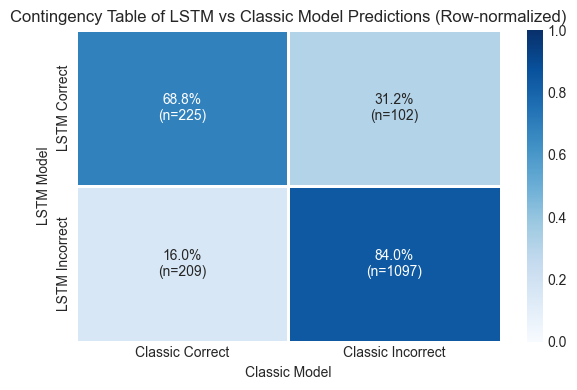

In [27]:
# Draw a graph of the contingency table as a heatmap
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

contingency_df = pd.DataFrame(
    contingency_table,
    index=['LSTM Correct', 'LSTM Incorrect'],
    columns=['Classic Correct', 'Classic Incorrect']
)

# Row-normalized
contingency_df_normalized = contingency_df.div(
    contingency_df.sum(axis=1), axis=0
)

# Build annotation strings: percentage + absolute count
annot = contingency_df_normalized.copy().astype(str)
for i in range(contingency_df.shape[0]):
    for j in range(contingency_df.shape[1]):
        pct = contingency_df_normalized.iloc[i, j]
        count = contingency_df.iloc[i, j]
        annot.iloc[i, j] = f"{pct:.1%}\n(n={count})"

plt.figure(figsize=(6, 4))
sns.heatmap(
    contingency_df_normalized,
    annot=annot,
    fmt="",
    cmap="Blues",
    vmin=0,
    vmax=1,
    linewidths=1,
)

plt.title("Contingency Table of LSTM vs Classic Model Predictions (Row-normalized)")
plt.ylabel("LSTM Model")
plt.xlabel("Classic Model")
plt.tight_layout()
plt.show()
